# 🚢 Titanic - Machine Learning from Disaster

## Phase 7: Hyperparameter Tuning & Model Optimization

### Objective

In Phase 5, we established reliable baseline models using Stratified K-Fold Cross-Validation.

In Phase 6, we investigated whether our engineered features actually improved model performance and identified promising feature sets for different model families.

We are now ready to optimize the models themselves.

The objective of this notebook is to systematically tune the hyperparameters of our strongest candidate models while maintaining a disciplined validation framework.

---

## What Are Hyperparameters?

Hyperparameters are configuration values that control how a machine learning algorithm learns.

Unlike model parameters, hyperparameters are not learned directly from the training data.


# 1. Import Libraries

We will import libraries required

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
import json
import joblib

from sklearn.model_selection import (
    StratifiedKFold,
    RandomizedSearchCV,
    cross_validate
)

from sklearn.compose import (
    ColumnTransformer
)

from sklearn.pipeline import (
    Pipeline
)

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import (
    SimpleImputer
)

from sklearn.linear_model import (
    LogisticRegression
)

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

import warnings

warnings.filterwarnings("ignore")

%matplotlib inline

sns.set_theme(
    style="whitegrid"
)

print(
    "Libraries imported successfully."
)

Libraries imported successfully.


# 2. Define Project Paths

To keep the notebook organized, we will define the locations of:

* Processed data.
* Phase 6 results.
* Saved models.


In [2]:
data_dir = Path(
    "../data/processed"
)

results_dir = Path(
    "../results"
)

models_dir = Path(
    "../models"
)


results_dir.mkdir(
    parents=True,
    exist_ok=True
)

models_dir.mkdir(
    parents=True,
    exist_ok=True
)


print(
    f"Data directory: {data_dir}"
)

print(
    f"Results directory: {results_dir}"
)

print(
    f"Models directory: {models_dir}"
)

Data directory: ../data/processed
Results directory: ../results
Models directory: ../models


# 3. Load Feature-Engineered Data

We will load the same feature-engineered training dataset used during baseline modeling and feature ablation.

The test dataset is not required during hyperparameter search.

Hyperparameter selection should be based entirely on the training data and cross-validation.

The competition test set will be used later when generating final Kaggle submissions.


In [3]:
train = pd.read_csv(
    data_dir /
    "train_featured.csv"
)


print(
    "Training dataset loaded successfully."
)

print(
    f"Shape: {train.shape}"
)

Training dataset loaded successfully.
Shape: (891, 26)


# 4. Load Feature Ablation Results

Phase 6 identified the strongest progressive feature set for each model.

We saved these results so that model selection decisions would be based on actual experimental evidence rather than assumptions.

We will now load:

`best_feature_sets_by_model.csv`

This file contains the strongest feature-set name identified for each model during Phase 6.


In [4]:
best_feature_results = pd.read_csv(
    results_dir /
    "best_feature_sets_by_model.csv"
)


print(
    "Phase 6 best feature-set results:"
)


display(
    best_feature_results
)

Phase 6 best feature-set results:


,Model,Feature Set,N Features,Train Accuracy,Mean CV Accuracy,CV Std,Min CV Accuracy,Max CV Accuracy,Train-CV Gap,Improvement vs Core
0,Gradient Boosting,04_Add_Cabin,13,0.907126,0.838359,0.018781,0.808989,0.860335,0.068767,0.003358
1,Logistic Regression,02_Core_Title,8,0.833332,0.836131,0.009794,0.820225,0.848315,-0.002798,0.033658
2,Random Forest,07_Add_Interaction,21,0.992704,0.840619,0.009936,0.825843,0.853933,0.152085,0.021317


In [5]:
y = train[
    "Survived"
].copy()


print(
    f"Target shape: {y.shape}"
)

print(
    "\nTarget distribution:"
)

print(
    y.value_counts()
)

Target shape: (891,)

Target distribution:
Survived
0    549
1    342
Name: count, dtype: int64


# 5. Reconstruct Feature Sets

The Phase 6 results store the name of the strongest feature set for each model.

To use those results during tuning, we need to reconstruct the exact feature combinations associated with each experiment.

These definitions must remain identical to those used during feature ablation.

This ensures that the hyperparameter tuning experiments are directly comparable with our Phase 6 results.


In [6]:
core_features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]


title_features = [
    "Title"
]


family_features = [
    "FamilySize",
    "IsAlone",
    "FamilyCategory"
]


cabin_features = [
    "CabinKnown",
    "Deck"
]


ticket_features = [
    "TicketGroupSize",
    "TicketPrefix",
    "FarePerPerson",
    "LogFare"
]


age_features = [
    "AgeMissing",
    "IsChild",
    "AgeGroup"
]


interaction_features = [
    "Sex_Pclass"
]


all_candidate_features = (
    core_features
    + title_features
    + family_features
    + cabin_features
    + ticket_features
    + age_features
    + interaction_features
)

In [7]:
feature_sets = {

    "01_Core":
        core_features,

    "02_Core_Title":
        core_features
        + title_features,

    "03_Add_Family":
        core_features
        + title_features
        + family_features,

    "04_Add_Cabin":
        core_features
        + title_features
        + family_features
        + cabin_features,

    "05_Add_Ticket":
        core_features
        + title_features
        + family_features
        + cabin_features
        + ticket_features,

    "06_Add_Age":
        core_features
        + title_features
        + family_features
        + cabin_features
        + ticket_features
        + age_features,

    "07_Add_Interaction":
        all_candidate_features,

    "08_All_Features":
        all_candidate_features
}


print(
    f"Number of reconstructed feature sets: "
    f"{len(feature_sets)}"
)

Number of reconstructed feature sets: 8


# 6. Recover the Best Feature Set for Each Model

We will use the Phase 6 results to determine which feature set should be paired with each model during tuning.

This prevents us from automatically forcing every model to use the complete engineered feature set.

Different model families may perform best with different feature representations.


In [8]:
selected_feature_sets = {}


for _, row in (
    best_feature_results.iterrows()
):

    model_name = row[
        "Model"
    ]

    feature_set_name = row[
        "Feature Set"
    ]


    if feature_set_name not in feature_sets:

        raise ValueError(
            f"Unknown feature set: "
            f"{feature_set_name}"
        )


    selected_feature_sets[
        model_name
    ] = feature_sets[
        feature_set_name
    ]


for model_name, features in (
    selected_feature_sets.items()
):

    print(
        "\n"
        + "=" * 60
    )

    print(
        model_name
    )

    print(
        f"Features: {len(features)}"
    )

    print(
        "=" * 60
    )

    print(
        features
    )


Gradient Boosting
Features: 13
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'FamilyCategory', 'CabinKnown', 'Deck']

Logistic Regression
Features: 8
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title']

Random Forest
Features: 21
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'FamilyCategory', 'CabinKnown', 'Deck', 'TicketGroupSize', 'TicketPrefix', 'FarePerPerson', 'LogFare', 'AgeMissing', 'IsChild', 'AgeGroup', 'Sex_Pclass']


In [9]:
known_categorical_features = [
    "Pclass",
    "Sex",
    "Embarked",
    "Title",
    "FamilyCategory",
    "Deck",
    "TicketPrefix",
    "AgeGroup",
    "Sex_Pclass"
]


def split_feature_types(
    selected_features
):

    categorical = [
        feature
        for feature
        in selected_features
        if feature
        in known_categorical_features
    ]


    numerical = [
        feature
        for feature
        in selected_features
        if feature
        not in known_categorical_features
    ]


    return (
        numerical,
        categorical
    )

# 7. Create the Preprocessing Pipeline

We will reuse the same preprocessing strategy used during baseline modeling and feature ablation.

Numerical features will receive:

* Median imputation.
* Standard scaling.

Categorical features will receive:

* Most-frequent imputation.
* One-hot encoding.

The preprocessing steps will remain inside the Scikit-learn pipeline.

This is important because preprocessing must be fitted independently within each cross-validation training fold.


In [10]:
def create_preprocessor(
    selected_features
):

    numerical_features, categorical_features = (
        split_feature_types(
            selected_features
        )
    )


    numeric_transformer = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                )
            ),
            (
                "scaler",
                StandardScaler()
            )
        ]
    )


    categorical_transformer = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ]
    )


    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                numeric_transformer,
                numerical_features
            ),
            (
                "categorical",
                categorical_transformer,
                categorical_features
            )
        ]
    )


    return preprocessor

# 8. Define Cross-Validation Strategy

We will continue using Stratified 5-Fold Cross-Validation.

Using the same validation strategy across baseline modeling, feature ablation, and hyperparameter tuning helps maintain consistency throughout the project.

However, there is an important consideration.

The best hyperparameter search score is obtained from the same cross-validation procedure used to select the hyperparameters.

Therefore, it may be slightly optimistic.

Later, we will use additional validation strategies when comparing final model candidates and ensembles.


In [11]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


print(
    "Cross-validation strategy created."
)

Cross-validation strategy created.


# 9. Define Untuned Reference Models

Before tuning, we will recreate the same model configurations used during feature ablation.

These models provide our reference performance.

After hyperparameter tuning, we will compare tuned models against these untuned versions.

This allows us to determine whether tuning actually produces measurable improvement.


In [12]:
base_models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=2000,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        )
}

In [13]:
models_to_tune = {}


for model_name in (
    selected_feature_sets.keys()
):

    if model_name in base_models:

        models_to_tune[
            model_name
        ] = base_models[
            model_name
        ]


print(
    "Models available for tuning:"
)


for model_name in models_to_tune:

    print(
        f"- {model_name}"
    )

Models available for tuning:
- Gradient Boosting
- Logistic Regression
- Random Forest


# 10. Re-Evaluate Untuned Model-Feature Combinations

Before tuning, we will evaluate each selected model using its strongest Phase 6 feature set.

These scores will serve as the direct reference point for evaluating the benefit of hyperparameter optimization.


In [14]:
untuned_results = []


for model_name, model in (
    models_to_tune.items()
):

    selected_features = (
        selected_feature_sets[
            model_name
        ]
    )


    X = train[
        selected_features
    ].copy()


    preprocessor = (
        create_preprocessor(
            selected_features
        )
    )


    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "classifier",
                model
            )
        ]
    )


    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring="accuracy",
        return_train_score=True,
        n_jobs=-1
    )


    untuned_results.append({

        "Model":
            model_name,

        "Feature Set":
            best_feature_results.loc[
                best_feature_results[
                    "Model"
                ] == model_name,
                "Feature Set"
            ].iloc[0],

        "Mean CV Accuracy":
            scores[
                "test_score"
            ].mean(),

        "CV Std":
            scores[
                "test_score"
            ].std(),

        "Train Accuracy":
            scores[
                "train_score"
            ].mean(),

        "Train-CV Gap":
            scores[
                "train_score"
            ].mean()
            -
            scores[
                "test_score"
            ].mean()
    })


untuned_df = pd.DataFrame(
    untuned_results
)


untuned_df.round(4)

,Model,Feature Set,Mean CV Accuracy,CV Std,Train Accuracy,Train-CV Gap
0,Gradient Boosting,04_Add_Cabin,0.8384,0.0188,0.9071,0.0688
1,Logistic Regression,02_Core_Title,0.8361,0.0098,0.8333,-0.0028
2,Random Forest,07_Add_Interaction,0.8406,0.0099,0.9927,0.1521


# 11. Define Hyperparameter Search Spaces

We will now define a broad but controlled search space for each model.

The parameter names begin with:

`classifier__`

because the model is stored inside a pipeline step named `classifier`.

---

## Logistic Regression

We will tune:

* `C`: Controls regularization strength.
* `penalty`: Determines the regularization type.
* `class_weight`: Tests whether balancing classes improves performance.

---

## Random Forest

We will tune:

* Number of trees.
* Maximum tree depth.
* Minimum samples required to split.
* Minimum samples required at leaves.
* Number of features considered during splits.
* Class weighting.

---

## Gradient Boosting

We will tune:

* Number of estimators.
* Learning rate.
* Maximum tree depth.
* Minimum samples required for splits.
* Minimum samples required at leaves.
* Subsampling rate.
* Number of features considered during splits.

The search spaces are intentionally broad enough to explore meaningful alternatives while remaining computationally manageable for the Titanic dataset.


In [15]:
param_distributions = {

    "Logistic Regression": {

        "classifier__C":
            np.logspace(
                -3,
                2,
                30
            ),

        "classifier__penalty": [
            "l1",
            "l2"
        ],

        "classifier__solver": [
            "liblinear"
        ],

        "classifier__class_weight": [
            None,
            "balanced"
        ]
    },


    "Random Forest": {

        "classifier__n_estimators": [
            200,
            300,
            500,
            700,
            1000
        ],

        "classifier__max_depth": [
            None,
            3,
            4,
            5,
            6,
            8,
            10
        ],

        "classifier__min_samples_split": [
            2,
            4,
            6,
            8,
            10
        ],

        "classifier__min_samples_leaf": [
            1,
            2,
            3,
            4,
            5
        ],

        "classifier__max_features": [
            "sqrt",
            "log2",
            None
        ],

        "classifier__class_weight": [
            None,
            "balanced"
        ]
    },


    "Gradient Boosting": {

        "classifier__n_estimators": [
            50,
            100,
            150,
            200,
            300
        ],

        "classifier__learning_rate": [
            0.01,
            0.03,
            0.05,
            0.1,
            0.2
        ],

        "classifier__max_depth": [
            1,
            2,
            3,
            4,
            5
        ],

        "classifier__min_samples_split": [
            2,
            4,
            6,
            8,
            10
        ],

        "classifier__min_samples_leaf": [
            1,
            2,
            3,
            4,
            5
        ],

        "classifier__subsample": [
            0.6,
            0.7,
            0.8,
            0.9,
            1.0
        ],

        "classifier__max_features": [
            None,
            "sqrt",
            "log2"
        ]
    }
}

# 12. Perform Randomized Hyperparameter Search

We will now run `RandomizedSearchCV` for each candidate model.

For each model:

1. Use its strongest feature set from Phase 6.
2. Build the appropriate preprocessing pipeline.
3. Randomly sample hyperparameter combinations.
4. Evaluate each configuration using Stratified 5-Fold Cross-Validation.
5. Select the configuration with the highest mean validation accuracy.

Because Random Forest and Gradient Boosting have larger search spaces, we will evaluate more parameter combinations for these models.

The process may take several minutes depending on your computer.


In [16]:
search_results = []

best_searches = {}


for model_name, model in (
    models_to_tune.items()
):

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"TUNING: {model_name}"
    )

    print(
        "=" * 70
    )


    selected_features = (
        selected_feature_sets[
            model_name
        ]
    )


    X = train[
        selected_features
    ].copy()


    preprocessor = (
        create_preprocessor(
            selected_features
        )
    )


    pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "classifier",
                model
            )
        ]
    )


    if model_name == "Logistic Regression":

        n_iter = 40

    else:

        n_iter = 60


    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=(
            param_distributions[
                model_name
            ]
        ),
        n_iter=n_iter,
        scoring="accuracy",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1,
        return_train_score=True,
        refit=True
    )


    search.fit(
        X,
        y
    )


    best_searches[
        model_name
    ] = search


    best_index = (
        search.best_index_
    )


    search_results.append({

        "Model":
            model_name,

        "Best CV Accuracy":
            search.best_score_,

        "Best CV Std":
            search.cv_results_[
                "std_test_score"
            ][best_index],

        "Best Train Accuracy":
            search.cv_results_[
                "mean_train_score"
            ][best_index],

        "Train-CV Gap":
            search.cv_results_[
                "mean_train_score"
            ][best_index]
            -
            search.best_score_,

        "Best Parameters":
            search.best_params_
    })


    print(
        f"\nBest CV Accuracy: "
        f"{search.best_score_:.4f}"
    )


    print(
        "\nBest Parameters:"
    )


    for parameter, value in (
        search.best_params_.items()
    ):

        print(
            f"{parameter}: {value}"
        )


TUNING: Gradient Boosting
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best CV Accuracy: 0.8384

Best Parameters:
classifier__subsample: 0.7
classifier__n_estimators: 100
classifier__min_samples_split: 4
classifier__min_samples_leaf: 3
classifier__max_features: None
classifier__max_depth: 5
classifier__learning_rate: 0.05

TUNING: Logistic Regression
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best CV Accuracy: 0.8361

Best Parameters:
classifier__solver: liblinear
classifier__penalty: l2
classifier__class_weight: None
classifier__C: 0.5736152510448681

TUNING: Random Forest
Fitting 5 folds for each of 60 candidates, totalling 300 fits

Best CV Accuracy: 0.8541

Best Parameters:
classifier__n_estimators: 1000
classifier__min_samples_split: 4
classifier__min_samples_leaf: 1
classifier__max_features: None
classifier__max_depth: 8
classifier__class_weight: balanced


In [17]:
tuned_df = pd.DataFrame(
    search_results
)


tuned_df = (
    tuned_df
    .sort_values(
        "Best CV Accuracy",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


tuned_df[
    [
        "Model",
        "Best CV Accuracy",
        "Best CV Std",
        "Best Train Accuracy",
        "Train-CV Gap"
    ]
].round(4)

,Model,Best CV Accuracy,Best CV Std,Best Train Accuracy,Train-CV Gap
0,Random Forest,0.8541,0.0169,0.9310,0.0769
1,Gradient Boosting,0.8384,0.0122,0.9265,0.0881
2,Logistic Regression,0.8361,0.0098,0.8328,-0.0034


# 13. Inspect the Best Hyperparameters

The selected hyperparameters provide insight into the type of model complexity favored by cross-validation.

For example:

* A shallow Random Forest may indicate that unrestricted trees were overfitting.
* Larger `min_samples_leaf` values may indicate that smoother decision boundaries generalize better.
* A lower Gradient Boosting learning rate may require more estimators but produce more controlled learning.
* Stronger Logistic Regression regularization may indicate that some encoded features contain redundant information.

We should interpret these parameters together with validation performance rather than assuming that more complex configurations are always better.


In [18]:
for model_name, search in (
    best_searches.items()
):

    print(
        "\n"
        + "=" * 70
    )

    print(
        model_name
    )

    print(
        "=" * 70
    )


    print(
        f"Best CV Score: "
        f"{search.best_score_:.4f}"
    )


    print(
        "\nBest Parameters:"
    )


    for param, value in (
        search.best_params_.items()
    ):

        print(
            f"{param}: {value}"
        )


Gradient Boosting
Best CV Score: 0.8384

Best Parameters:
classifier__subsample: 0.7
classifier__n_estimators: 100
classifier__min_samples_split: 4
classifier__min_samples_leaf: 3
classifier__max_features: None
classifier__max_depth: 5
classifier__learning_rate: 0.05

Logistic Regression
Best CV Score: 0.8361

Best Parameters:
classifier__solver: liblinear
classifier__penalty: l2
classifier__class_weight: None
classifier__C: 0.5736152510448681

Random Forest
Best CV Score: 0.8541

Best Parameters:
classifier__n_estimators: 1000
classifier__min_samples_split: 4
classifier__min_samples_leaf: 1
classifier__max_features: None
classifier__max_depth: 8
classifier__class_weight: balanced


# 14. Compare Untuned and Tuned Models

Hyperparameter tuning is useful only if it produces meaningful improvement.

We will compare each model's:

* Untuned cross-validation accuracy.
* Best tuning cross-validation accuracy.
* Absolute improvement.

A very small improvement should be interpreted cautiously because it may fall within normal cross-validation variability.

We should not automatically prefer a highly tuned configuration if its apparent advantage is negligible.


In [19]:
comparison_results = []


for _, untuned_row in (
    untuned_df.iterrows()
):

    model_name = (
        untuned_row[
            "Model"
        ]
    )


    tuned_row = (
        tuned_df[
            tuned_df[
                "Model"
            ] == model_name
        ]
        .iloc[0]
    )


    comparison_results.append({

        "Model":
            model_name,

        "Untuned CV Accuracy":
            untuned_row[
                "Mean CV Accuracy"
            ],

        "Tuned CV Accuracy":
            tuned_row[
                "Best CV Accuracy"
            ],

        "Improvement":
            tuned_row[
                "Best CV Accuracy"
            ]
            -
            untuned_row[
                "Mean CV Accuracy"
            ],

        "Tuned CV Std":
            tuned_row[
                "Best CV Std"
            ],

        "Tuned Train-CV Gap":
            tuned_row[
                "Train-CV Gap"
            ]
    })


comparison_df = pd.DataFrame(
    comparison_results
)


comparison_df.round(4)

,Model,Untuned CV Accuracy,Tuned CV Accuracy,Improvement,Tuned CV Std,Tuned Train-CV Gap
0,Gradient Boosting,0.8384,0.8384,0.0000,0.0122,0.0881
1,Logistic Regression,0.8361,0.8361,0.0000,0.0098,-0.0034
2,Random Forest,0.8406,0.8541,0.0134,0.0169,0.0769


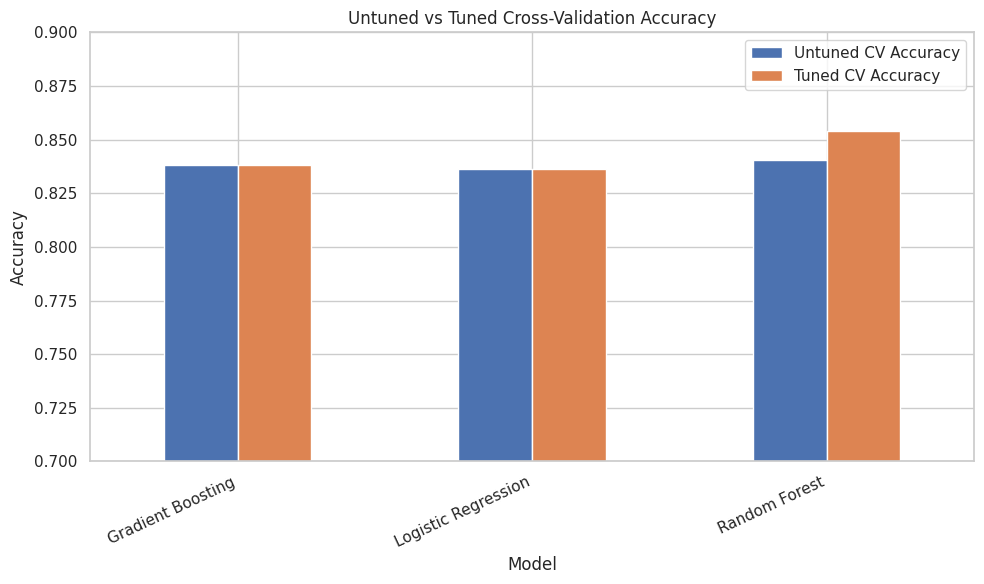

In [20]:
plot_df = (
    comparison_df[
        [
            "Model",
            "Untuned CV Accuracy",
            "Tuned CV Accuracy"
        ]
    ]
    .set_index(
        "Model"
    )
)


plot_df.plot(
    kind="bar",
    figsize=(10, 6)
)


plt.title(
    "Untuned vs Tuned Cross-Validation Accuracy"
)

plt.ylabel(
    "Accuracy"
)

plt.xlabel(
    "Model"
)

plt.ylim(
    0.70,
    0.90
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()

plt.show()

In [21]:
improvement_df = (
    comparison_df[
        [
            "Model",
            "Improvement"
        ]
    ]
    .sort_values(
        "Improvement",
        ascending=False
    )
)


improvement_df.round(4)

,Model,Improvement
2,Random Forest,0.0134
0,Gradient Boosting,0.0000
1,Logistic Regression,0.0000


# 15. Inspect Top Hyperparameter Configurations

Looking only at the single best configuration can be misleading.

Several hyperparameter combinations may achieve nearly identical cross-validation performance.

We will inspect the top configurations for each model.

If many configurations have very similar scores, this suggests that the model is relatively insensitive to small parameter changes within that region.

This is generally preferable to a situation where one isolated parameter combination performs unusually well.


In [22]:
top_search_results = {}


for model_name, search in (
    best_searches.items()
):

    model_results = pd.DataFrame(
        search.cv_results_
    )


    model_results = (
        model_results
        .sort_values(
            "mean_test_score",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )


    top_search_results[
        model_name
    ] = model_results


    print(
        "\n"
        + "=" * 70
    )

    print(
        f"TOP CONFIGURATIONS: "
        f"{model_name}"
    )

    print(
        "=" * 70
    )


    display(
        model_results[
            [
                "mean_train_score",
                "mean_test_score",
                "std_test_score",
                "params"
            ]
        ]
        .head(10)
    )


TOP CONFIGURATIONS: Gradient Boosting


,mean_train_score,mean_test_score,std_test_score,params
0,0.926486,0.838365,0.012213,"{'classifier__subsample': 0.7, 'classifier__n_..."
1,0.862232,0.837248,0.013903,"{'classifier__subsample': 0.6, 'classifier__n_..."
2,0.915263,0.837236,0.016501,"{'classifier__subsample': 1.0, 'classifier__n_..."
3,0.880470,0.837236,0.017249,"{'classifier__subsample': 0.9, 'classifier__n_..."
4,0.864758,0.836125,0.015787,"{'classifier__subsample': 0.7, 'classifier__n_..."
5,0.938271,0.836099,0.022807,"{'classifier__subsample': 1.0, 'classifier__n_..."
6,0.875702,0.835007,0.010557,"{'classifier__subsample': 0.8, 'classifier__n_..."
7,0.854656,0.833890,0.005847,"{'classifier__subsample': 0.9, 'classifier__n_..."
8,0.852410,0.833884,0.006009,"{'classifier__subsample': 0.6, 'classifier__n_..."
9,0.878506,0.833877,0.029728,"{'classifier__subsample': 0.6, 'classifier__n_..."



TOP CONFIGURATIONS: Logistic Regression


,mean_train_score,mean_test_score,std_test_score,params
0,0.832772,0.836131,0.009794,"{'classifier__solver': 'liblinear', 'classifie..."
1,0.834174,0.833884,0.012236,"{'classifier__solver': 'liblinear', 'classifie..."
2,0.835577,0.833877,0.015075,"{'classifier__solver': 'liblinear', 'classifie..."
3,0.833613,0.832760,0.009191,"{'classifier__solver': 'liblinear', 'classifie..."
4,0.836418,0.832754,0.015004,"{'classifier__solver': 'liblinear', 'classifie..."
5,0.835857,0.832754,0.015004,"{'classifier__solver': 'liblinear', 'classifie..."
6,0.836138,0.832754,0.015004,"{'classifier__solver': 'liblinear', 'classifie..."
7,0.833333,0.831643,0.012896,"{'classifier__solver': 'liblinear', 'classifie..."
8,0.836418,0.831636,0.013908,"{'classifier__solver': 'liblinear', 'classifie..."
9,0.835577,0.831636,0.013908,"{'classifier__solver': 'liblinear', 'classifie..."



TOP CONFIGURATIONS: Random Forest


,mean_train_score,mean_test_score,std_test_score,params
0,0.930976,0.854064,0.016888,"{'classifier__n_estimators': 1000, 'classifier..."
1,0.932379,0.847360,0.004263,"{'classifier__n_estimators': 300, 'classifier_..."
2,0.914420,0.847354,0.014026,"{'classifier__n_estimators': 300, 'classifier_..."
3,0.934623,0.847342,0.011144,"{'classifier__n_estimators': 500, 'classifier_..."
4,0.903198,0.843983,0.014065,"{'classifier__n_estimators': 700, 'classifier_..."
5,0.950897,0.843983,0.010462,"{'classifier__n_estimators': 500, 'classifier_..."
6,0.889730,0.843977,0.018047,"{'classifier__n_estimators': 300, 'classifier_..."
7,0.910493,0.843977,0.015810,"{'classifier__n_estimators': 300, 'classifier_..."
8,0.904321,0.842872,0.015492,"{'classifier__n_estimators': 700, 'classifier_..."
9,0.900112,0.842872,0.017769,"{'classifier__n_estimators': 500, 'classifier_..."


# 16. Rank the Tuned Models

We will rank the tuned models according to their best cross-validation accuracy.

However, our final model-selection decision should consider:

1. Mean validation accuracy.
2. Validation variability.
3. Training-validation gap.
4. Model complexity.
5. Performance differences between competing models.

A difference of a few thousandths in cross-validation accuracy is not necessarily strong evidence that one model is fundamentally superior.


In [23]:
model_ranking = (
    tuned_df[
        [
            "Model",
            "Best CV Accuracy",
            "Best CV Std",
            "Best Train Accuracy",
            "Train-CV Gap"
        ]
    ]
    .sort_values(
        "Best CV Accuracy",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


model_ranking.round(4)

,Model,Best CV Accuracy,Best CV Std,Best Train Accuracy,Train-CV Gap
0,Random Forest,0.8541,0.0169,0.9310,0.0769
1,Gradient Boosting,0.8384,0.0122,0.9265,0.0881
2,Logistic Regression,0.8361,0.0098,0.8328,-0.0034


In [24]:
best_tuned_model_name = (
    model_ranking
    .iloc[0][
        "Model"
    ]
)


best_tuned_score = (
    model_ranking
    .iloc[0][
        "Best CV Accuracy"
    ]
)


best_tuned_pipeline = (
    best_searches[
        best_tuned_model_name
    ]
    .best_estimator_
)


best_tuned_features = (
    selected_feature_sets[
        best_tuned_model_name
    ]
)


print(
    f"Strongest tuned model: "
    f"{best_tuned_model_name}"
)


print(
    f"Best search CV accuracy: "
    f"{best_tuned_score:.4f}"
)


print(
    f"Number of input features: "
    f"{len(best_tuned_features)}"
)

Strongest tuned model: Random Forest
Best search CV accuracy: 0.8541
Number of input features: 21


# 17. Important: Interpreting the Best Search Score

The `best_score_` produced by `RandomizedSearchCV` should not be treated as a perfectly unbiased estimate of future model performance.

Why?

Because we tested many hyperparameter configurations and selected the configuration that performed best on these cross-validation folds.

This introduces a degree of selection bias.

The more configurations we test, the greater the opportunity to select a configuration that benefited from random variation in the validation folds.

Therefore:

* The search score is useful for model selection.
* It should not be interpreted as guaranteed Kaggle leaderboard performance.
* Final model candidates should be compared using additional validation evidence.

In the advanced modeling phase, we will use stronger comparisons before selecting the final competition model.


# 18. Save Hyperparameter Tuning Results

We will save:

* Untuned model results.
* Tuned model results.
* Tuned vs untuned comparison.
* Best hyperparameters.

This allows us to track how much improvement was produced by tuning and preserves the exact configurations for later experiments.


In [25]:
untuned_df.to_csv(
    results_dir /
    "untuned_model_results.csv",
    index=False
)


tuned_df.to_csv(
    results_dir /
    "hyperparameter_tuning_results.csv",
    index=False
)


comparison_df.to_csv(
    results_dir /
    "tuned_vs_untuned_results.csv",
    index=False
)


print(
    "Tuning result files saved successfully."
)

Tuning result files saved successfully.


In [26]:
best_parameters = {}


for model_name, search in (
    best_searches.items()
):

    best_parameters[
        model_name
    ] = search.best_params_


parameters_path = (
    results_dir /
    "best_hyperparameters.json"
)


with open(
    parameters_path,
    "w"
) as file:

    json.dump(
        best_parameters,
        file,
        indent=4
    )


print(
    f"Best parameters saved to:"
)

print(
    parameters_path
)

Best parameters saved to:
../results/best_hyperparameters.json


# 19. Save the Tuned Model Pipelines

We will save the best tuned pipeline for each model.

Each saved pipeline contains:

* Preprocessing logic.
* Categorical encoding.
* Numerical preprocessing.
* The tuned classifier.

Saving the complete pipeline is safer than saving only the classifier because the exact preprocessing required by the model remains attached to it.

These models are not yet considered our final competition models.

They are saved as candidates for the advanced modeling and ensemble phase.


In [27]:
for model_name, search in (
    best_searches.items()
):

    safe_name = (
        model_name
        .lower()
        .replace(
            " ",
            "_"
        )
    )


    model_path = (
        models_dir /
        f"tuned_{safe_name}.pkl"
    )


    joblib.dump(
        search.best_estimator_,
        model_path
    )


    print(
        f"Saved: {model_path}"
    )

Saved: ../models/tuned_gradient_boosting.pkl
Saved: ../models/tuned_logistic_regression.pkl
Saved: ../models/tuned_random_forest.pkl


In [28]:
feature_mapping = {}


for model_name, features in (
    selected_feature_sets.items()
):

    feature_mapping[
        model_name
    ] = features


feature_mapping_path = (
    results_dir /
    "model_feature_mapping.json"
)


with open(
    feature_mapping_path,
    "w"
) as file:

    json.dump(
        feature_mapping,
        file,
        indent=4
    )


print(
    f"Feature mapping saved to:"
)

print(
    feature_mapping_path
)

Feature mapping saved to:
../results/model_feature_mapping.json


# 20. Hyperparameter Tuning Evaluation

After completing the searches, evaluate the results using the following questions.

## Question 1: Did Tuning Improve Performance?

Compare the tuned and untuned cross-validation scores.

If tuning produces only a very small improvement, the default or simpler model configuration may already be strong.

---

## Question 2: Did Tuning Reduce Overfitting?

Compare the training-validation gap before and after tuning.

For tree-based models, parameters such as:

* `max_depth`
* `min_samples_split`
* `min_samples_leaf`

can significantly reduce overfitting.

---

## Question 3: Is the Improvement Stable?

Compare cross-validation standard deviation.

An improvement in mean accuracy accompanied by substantially higher variability should be interpreted cautiously.

---

## Question 4: Are Several Configurations Equally Competitive?

Inspect the top hyperparameter configurations.

If several configurations achieve nearly identical scores, this indicates a stable high-performing parameter region.

---

## Question 5: Which Models Should Continue?

Do not automatically discard every model except the highest-scoring one.

Models with similar validation performance may make different prediction errors.

This diversity can become valuable when constructing ensembles.


# 21. Phase 7 Summary

In this notebook, we optimized the strongest model-feature combinations identified during feature ablation.

---

## Feature Selection

Rather than forcing every model to use the same features, we recovered the strongest feature set identified for each model during Phase 6.

This preserved the results of our earlier feature-selection experiments.

---

## Untuned Benchmarks

Before tuning, we re-evaluated each selected model-feature combination.

These results established the reference performance required to measure the actual benefit of hyperparameter optimization.

---

## Randomized Hyperparameter Search

We used `RandomizedSearchCV` to explore hyperparameter configurations for:

* Logistic Regression.
* Random Forest.
* Gradient Boosting.

Each configuration was evaluated using Stratified 5-Fold Cross-Validation.

---

## Tuned vs Untuned Comparison

We compared:

* Mean cross-validation accuracy.
* Cross-validation variability.
* Training-validation gap.
* Absolute improvement after tuning.

This allowed us to determine whether hyperparameter optimization produced meaningful improvements.

---

## Model Diagnostics

We inspected the highest-performing hyperparameter configurations rather than relying only on the single best result.

This helped us understand whether strong performance occurred across a stable region of the parameter space.

---

## Saved Artifacts

We saved:

### Results

* `untuned_model_results.csv`
* `hyperparameter_tuning_results.csv`
* `tuned_vs_untuned_results.csv`
* `best_hyperparameters.json`
* `model_feature_mapping.json`

### Model Pipelines

* Tuned Logistic Regression pipeline.
* Tuned Random Forest pipeline.
* Tuned Gradient Boosting pipeline.

These models will become candidates for the advanced modeling phase.